In [68]:
import time
import json
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import Normalize
from PIL import Image

from pc import PS
from modules import ADC,DAC,CHIP
from command import CMD,CmdData,Packet
from command.singleCmdInfo import *

from util import plot_v_cond,plot_cond,show_crossbar,DataLoader

from network.layer import Layer,WriteConfig

In [69]:
chip=CHIP(PS(host="192.168.1.10", port = 7, debug=0),init=True)
chip.set_device_cfg(deviceType=0)
chip.adc.set_gap(adc_cs_gap=100,adc_first_gap=20,adc_last_gap=10)
chip.add_compiler("./code/")

Connected to 192.168.1.10:7
local ip: 192.168.1.15 local port: 65138
正在编译文件:  ./code/read_point3.txt
正在编译文件:  ./code/read_point3_col.txt
正在编译文件:  ./code/row_read_point3.txt
正在编译文件:  ./code/set_reset.txt
正在编译文件:  ./code/write_verify.txt
正在编译文件:  ./code/汇编测试代码.txt
正在编译文件:  ./code/读任意大小的块-汇编代码示例.txt
正在编译文件:  ./code/读单点测试.txt


(100, 100)
0.16640375538417881 -0.13960279590415514


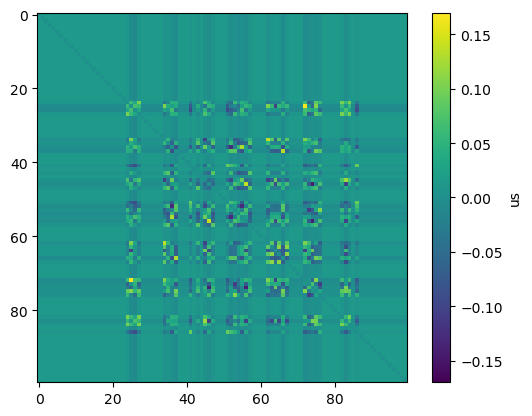

In [70]:
dl = DataLoader()
data = dl.load_csv("./data/HNN_W_matrix_origin.csv")
print(data.shape)
print(np.max(data),np.min(data))
plot_cond(data,vmin=-0.17,vmax=0.17)

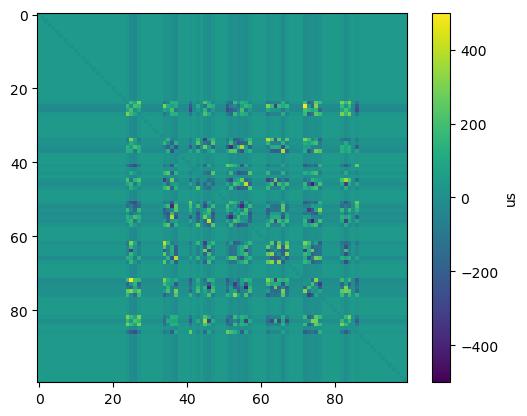

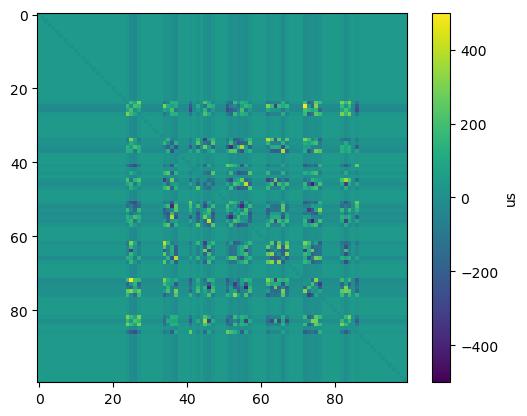

In [71]:
cond_min,cond_max,cond_reference = 200,1200,700
weight_min,weight_max = -0.17,0.17
target_cond = data/weight_max*(cond_max-cond_reference)
plot_cond(target_cond,vmin=-500,vmax=500)
plot_cond(target_cond.T,vmin=-500,vmax=500)

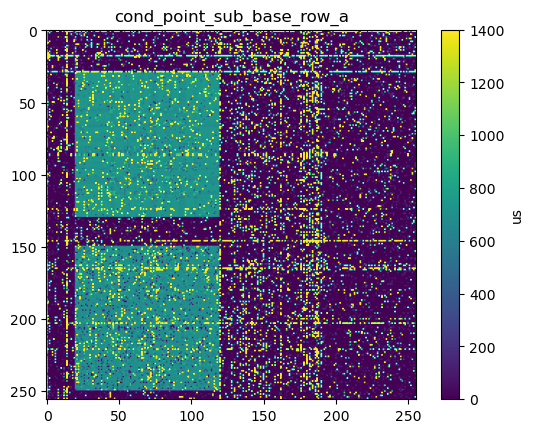

In [72]:
voltage_base_point_row_a = chip.read_point3(0,256,0,256,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
voltage_point_row_a = chip.read_point3(0,256,0,256,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
cond_sub_base_row_a = chip.voltage_to_cond(voltage=voltage_point_row_a-voltage_base_point_row_a)
plot_cond(cond_sub_base_row_a,title="cond_point_sub_base_row_a")

In [ ]:
chip.ps.receive_packet(4096)

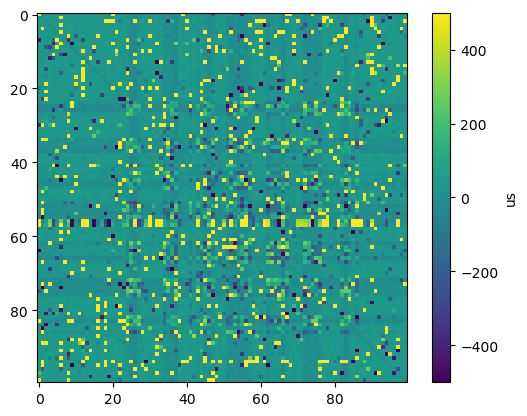

0 reset: 765 set 755


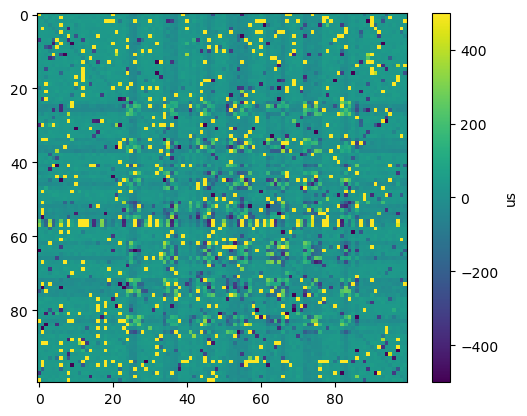

1 reset: 678 set 814


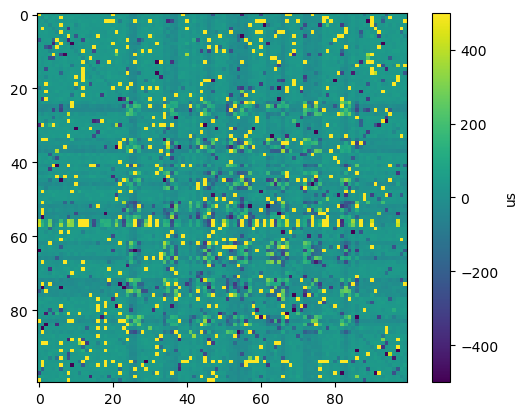

2 reset: 691 set 776


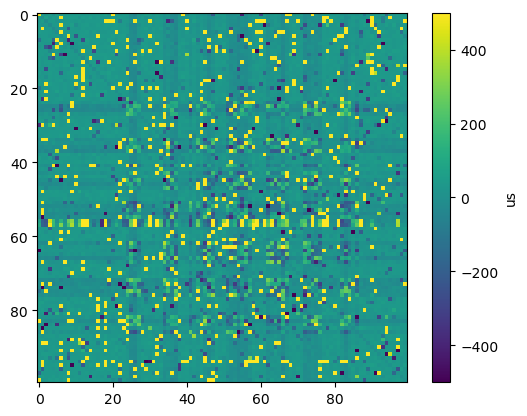

3 reset: 689 set 778


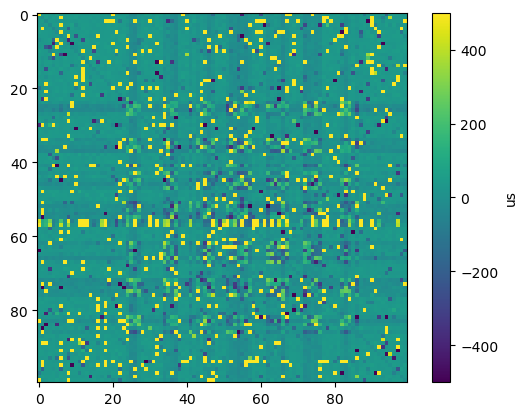

4 reset: 688 set 754


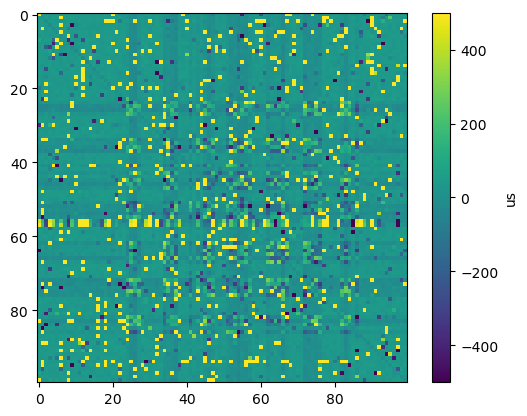

5 reset: 722 set 660


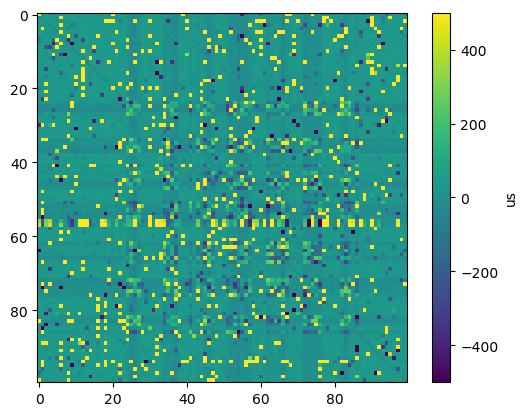

6 reset: 713 set 661


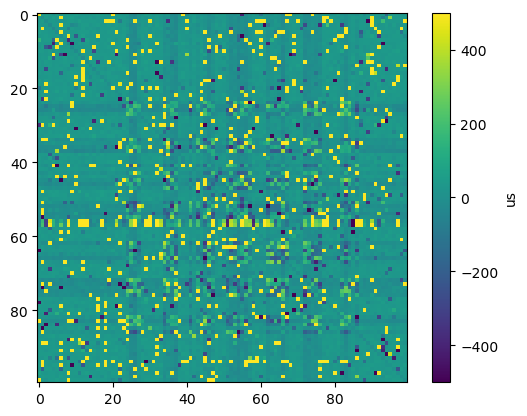

7 reset: 728 set 610


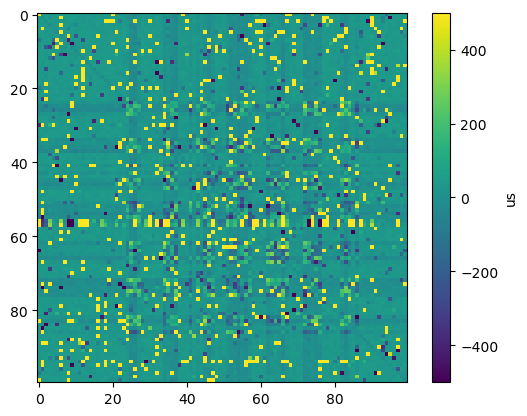

8 reset: 737 set 602


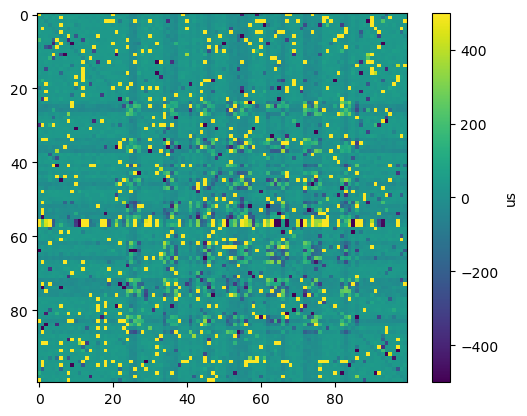

9 reset: 734 set 619


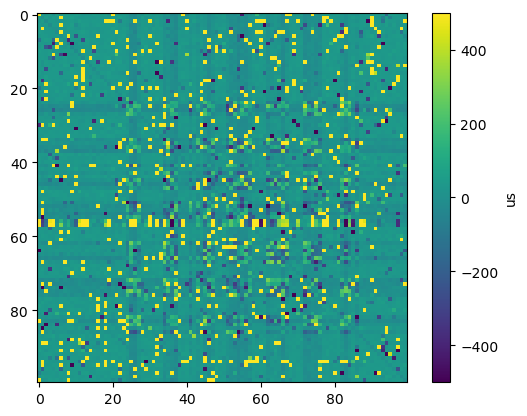

10 reset: 739 set 622


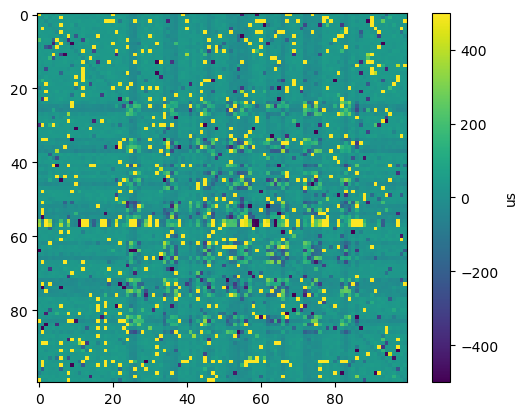

11 reset: 751 set 616


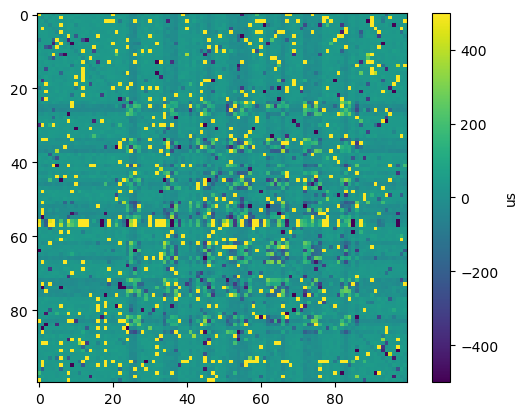

12 reset: 741 set 642


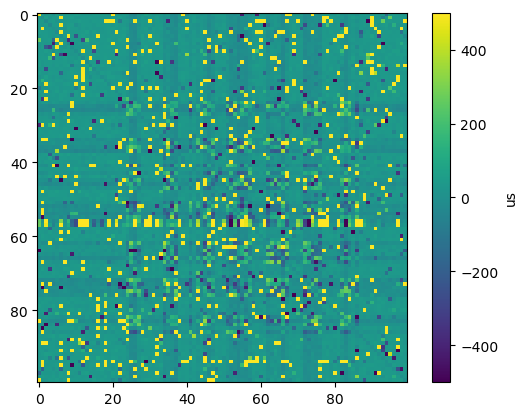

13 reset: 759 set 627


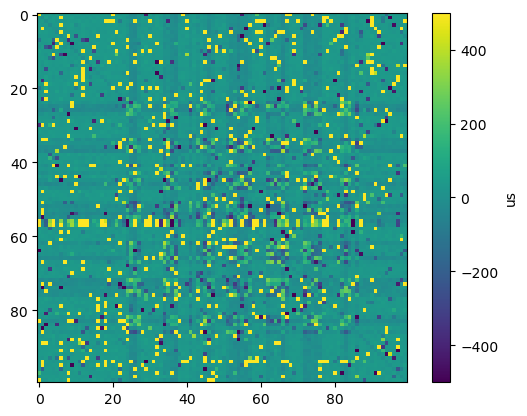

14 reset: 750 set 645


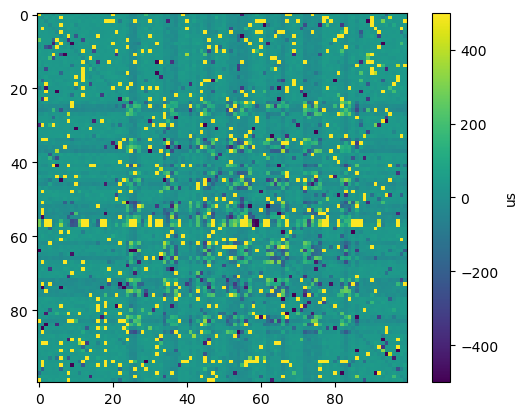

15 reset: 778 set 609


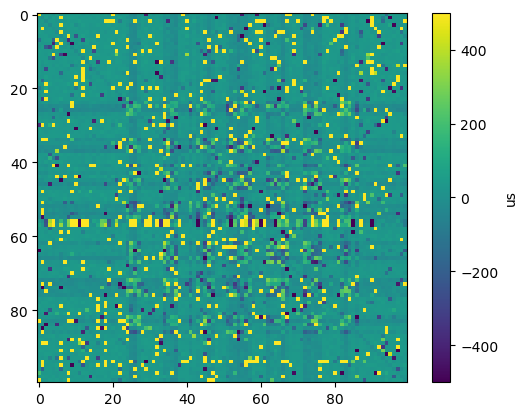

16 reset: 758 set 646


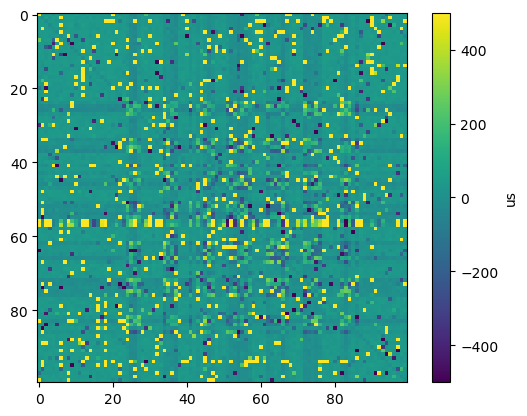

17 reset: 796 set 627


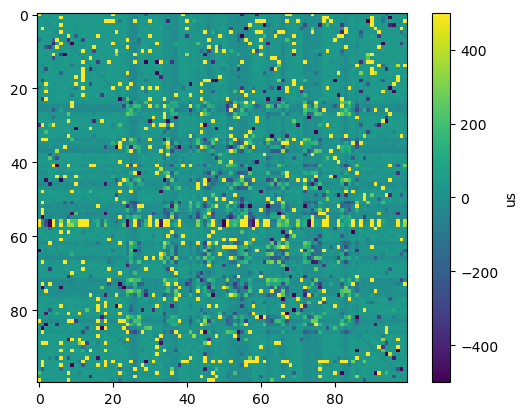

18 reset: 779 set 656


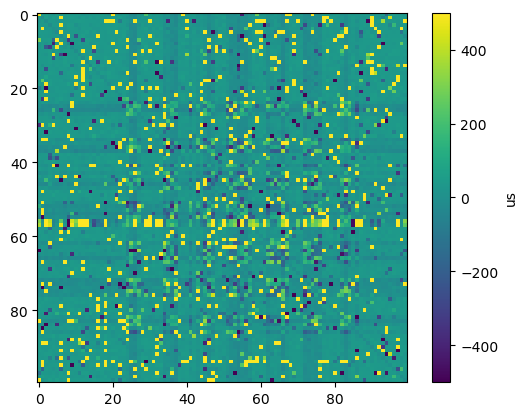

19 reset: 797 set 637


In [73]:
pos = (30,130,20,120)
target_cond_new = target_cond + cond_reference
target_cond_new = target_cond_new.T
threshold =25

set_v,reset_v = 3,2
reset_pulse_width,set_pulse_width = 1e-6,1e-6
need_write = np.ones((100,100),dtype=bool)
reset_cond = np.zeros((256,256),dtype=bool)
set_cond = np.zeros((256,256),dtype=bool)

tg_v = np.ones((256,256))*1.4
for i in range(20):
    voltage_base = chip.read_point3(*pos,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
    voltage = chip.read_point3(*pos,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
    cond = chip.voltage_to_cond(voltage=voltage-voltage_base)
    plot_cond(cond-700,vmin=-500,vmax=500)

    condition_reset = (cond > (target_cond_new+threshold)) 
    condition_set = (cond < (target_cond_new-threshold)) 
    need_write = condition_reset + condition_set
    print(i,"reset:",np.sum(condition_reset),"set",np.sum(condition_set))

    reset_cond[pos[0]:pos[1],pos[2]:pos[3]] = condition_reset
    set_cond[pos[0]:pos[1],pos[2]:pos[3]] = condition_set

    if i>0:
        set_v+=0.01
        # reset_v+=0.01
        if i<5:
            tg_v[reset_cond] -= 0.08
            tg_v[set_cond] += 0.08
        elif i<10:
            tg_v[reset_cond] -= 0.04
            tg_v[set_cond] += 0.04
        else:
            tg_v[reset_cond] -= 0.01
            tg_v[set_cond] += 0.01

    # reset的点
    chip.write_point2(crossbar=reset_cond,write_voltage=2,tg=5,pulse_width=1e-6,set_device=False)
    chip.write_point2(crossbar=reset_cond,write_voltage=2,tg=tg_v,pulse_width=set_pulse_width,set_device=True)

    # set的点
    chip.write_point2(crossbar=set_cond,write_voltage=set_v,tg=tg_v,pulse_width=set_pulse_width,set_device=True)


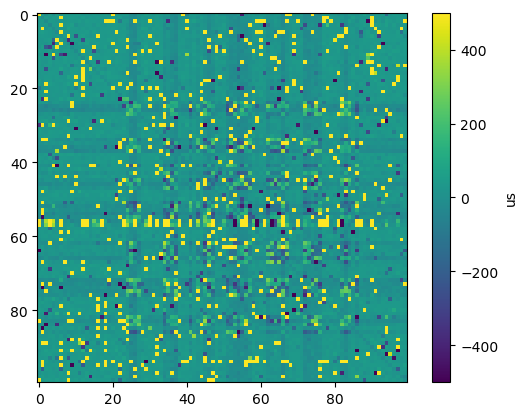

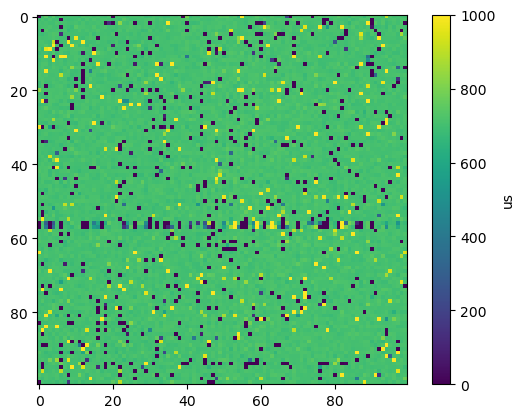

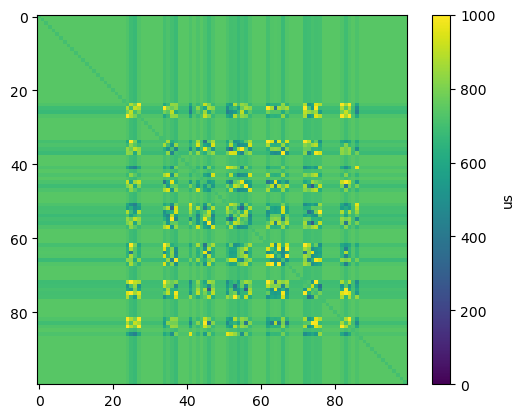

In [ ]:
pos = (30,130,20,120)
voltage_base = chip.read_point3(*pos,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
voltage = chip.read_point3(*pos,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
cond = chip.voltage_to_cond(voltage=voltage-voltage_base)
plot_cond(cond-700,vmin=-500,vmax=500)

target_cond2 = target_cond-(cond-700)+700

plot_cond(target_cond2,vmin=0,vmax=1000)

plot_cond(target_cond2+cond-700,vmin=0,vmax=1000)

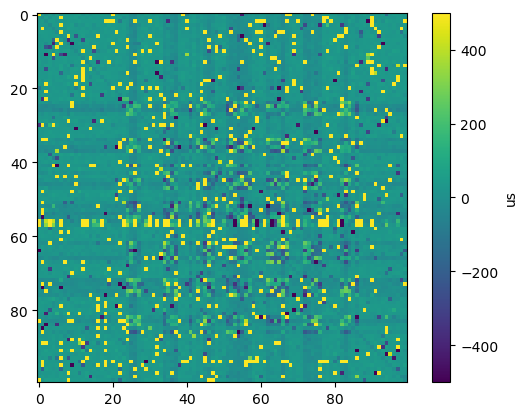

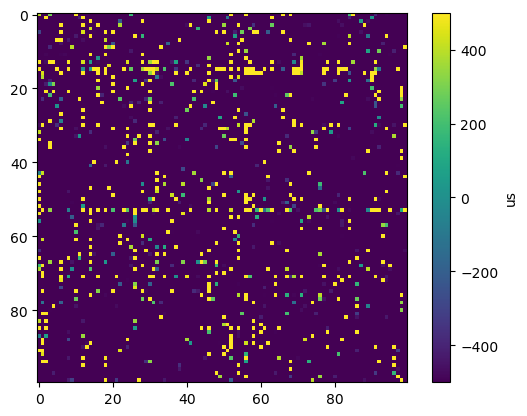

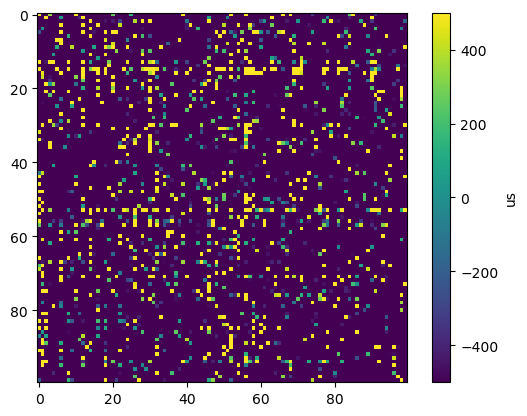

In [59]:
pos = (30,130,20,120)
voltage_base = chip.read_point3(*pos,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
voltage = chip.read_point3(*pos,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
cond = chip.voltage_to_cond(voltage=voltage-voltage_base)-700
plot_cond(cond,vmin=-500,vmax=500)

pos = (150,250,20,120)
voltage_base = chip.read_point3(*pos,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
voltage = chip.read_point3(*pos,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
target_cond2 = chip.voltage_to_cond(voltage=voltage-voltage_base)-1400

plot_cond(target_cond2,vmin=-500,vmax=500)

plot_cond(target_cond2+cond,vmin=-500,vmax=500)

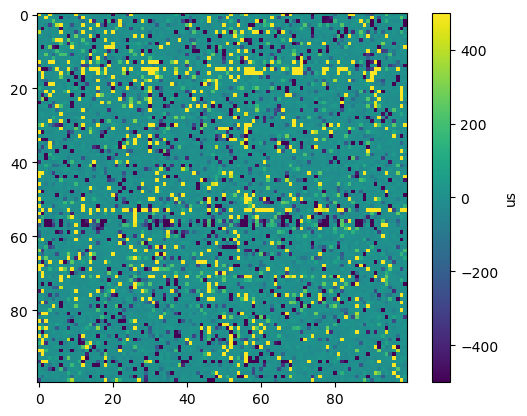

0 reset: 1047 set 1431


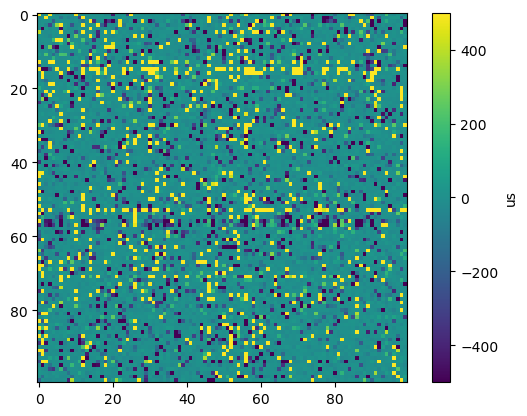

1 reset: 981 set 1510


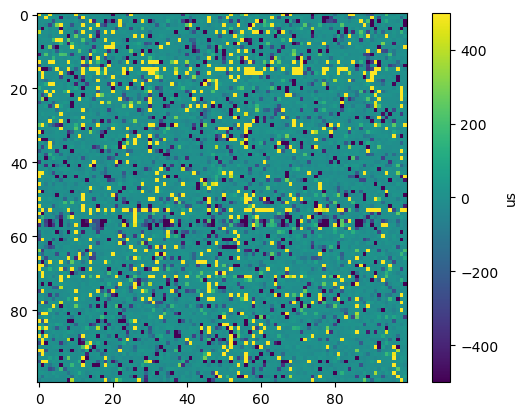

2 reset: 973 set 1518


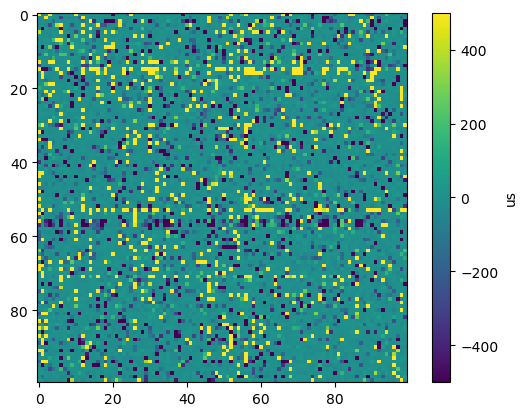

3 reset: 972 set 1515


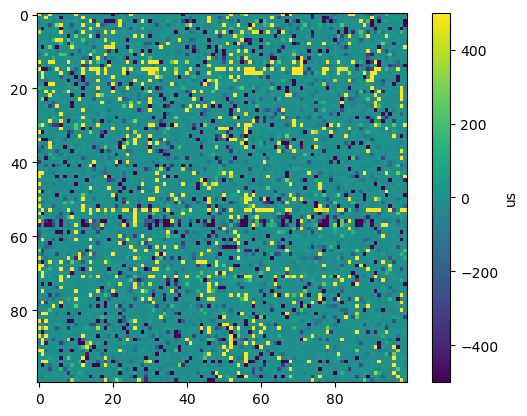

4 reset: 957 set 1510


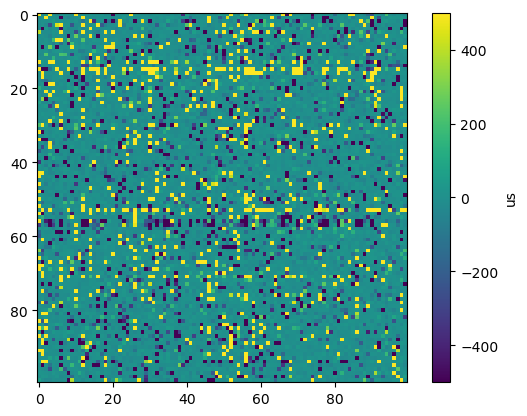

5 reset: 994 set 1347


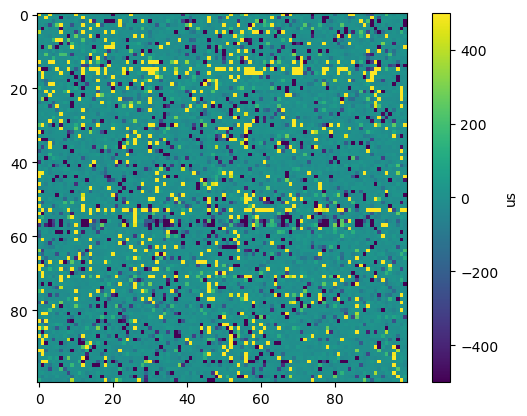

6 reset: 947 set 1333


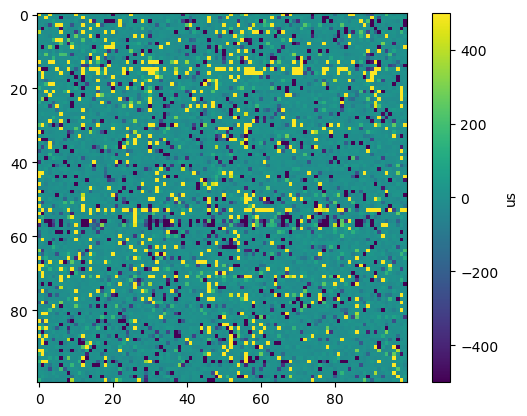

7 reset: 978 set 1281


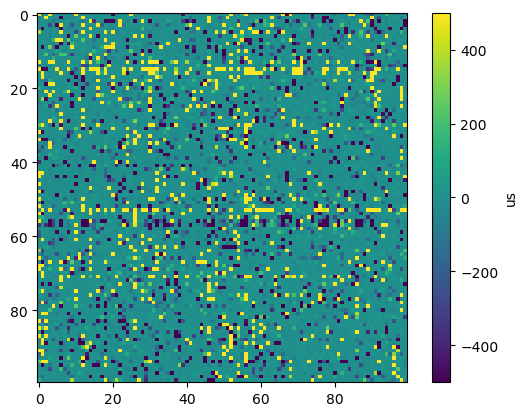

8 reset: 939 set 1336


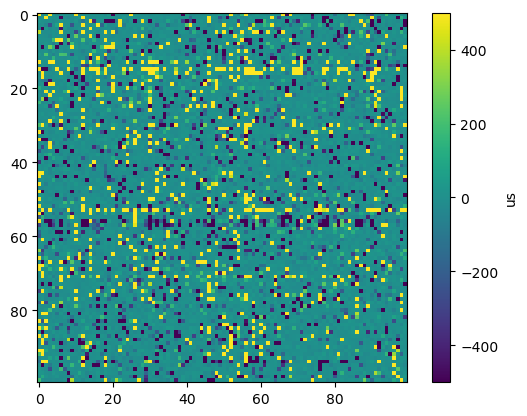

9 reset: 980 set 1299


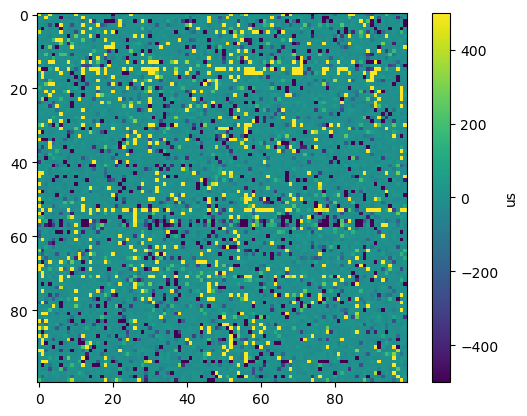

10 reset: 965 set 1315


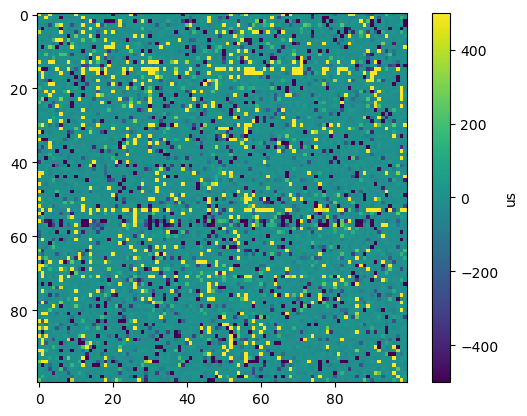

11 reset: 990 set 1317


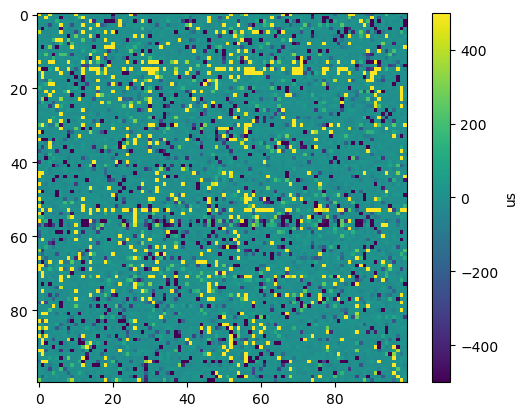

12 reset: 1009 set 1279


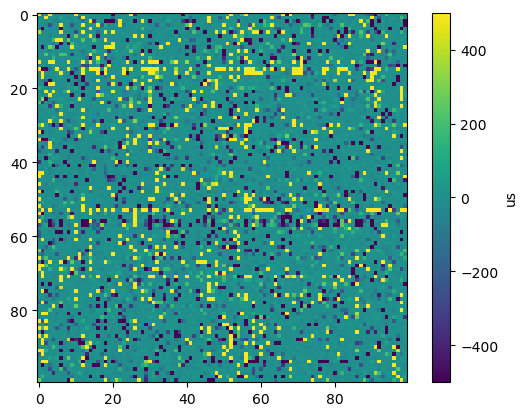

13 reset: 1021 set 1282


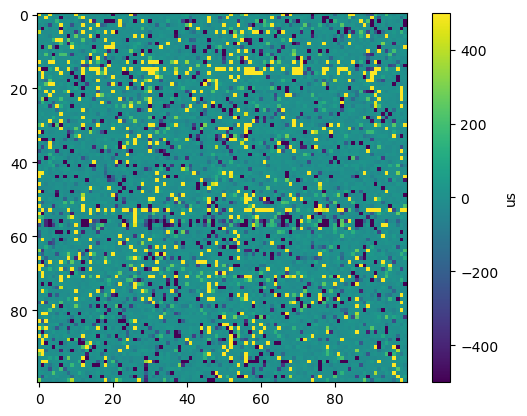

14 reset: 1029 set 1289


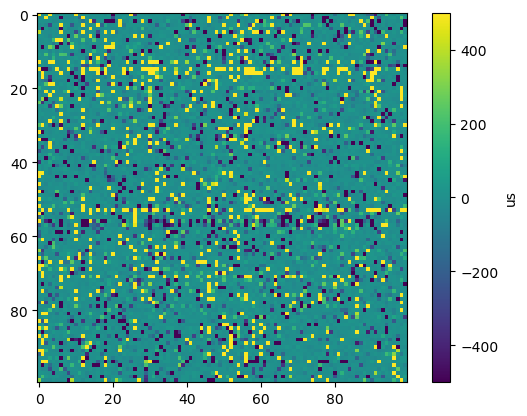

15 reset: 1060 set 1257


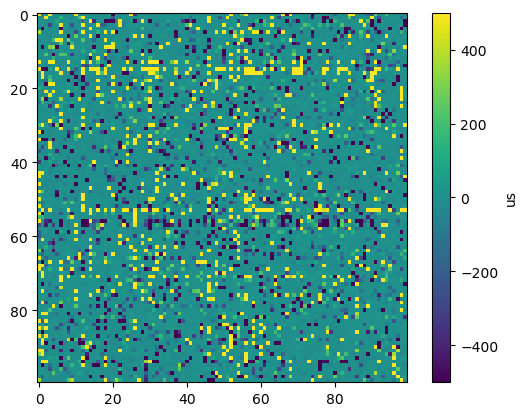

16 reset: 1048 set 1278


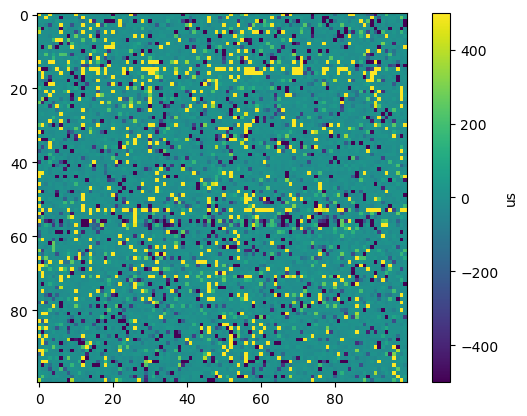

17 reset: 1068 set 1272


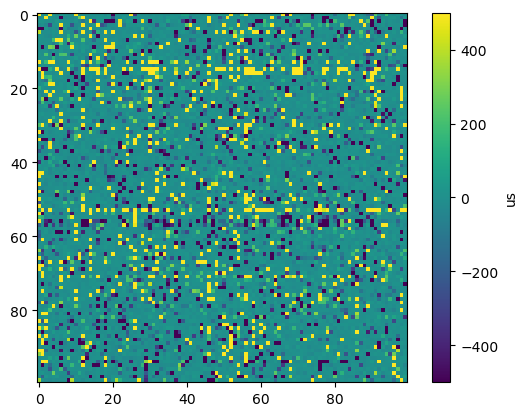

18 reset: 1069 set 1254


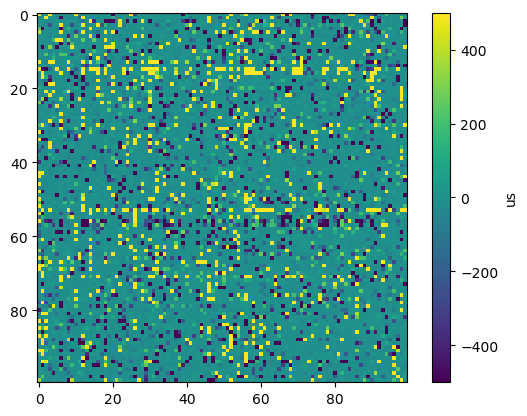

19 reset: 1087 set 1245


In [56]:
pos = (150,250,20,120)
target_cond_new = target_cond2
target_cond_new = target_cond_new.clip(50,1200)
threshold =25

set_v,reset_v = 2,2
reset_pulse_width,set_pulse_width = 1e-6,1e-6
need_write = np.ones((100,100),dtype=bool)
reset_cond = np.zeros((256,256),dtype=bool)
set_cond = np.zeros((256,256),dtype=bool)

tg_v = np.ones((256,256))*1.4
for i in range(20):
    voltage_base = chip.read_point3(*pos,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
    voltage = chip.read_point3(*pos,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
    cond = chip.voltage_to_cond(voltage=voltage-voltage_base)
    plot_cond(cond-700,vmin=-500,vmax=500)

    condition_reset = (cond > (target_cond_new+threshold)) 
    condition_set = (cond < (target_cond_new-threshold)) 
    need_write = condition_reset + condition_set
    print(i,"reset:",np.sum(condition_reset),"set",np.sum(condition_set))

    reset_cond[pos[0]:pos[1],pos[2]:pos[3]] = condition_reset
    set_cond[pos[0]:pos[1],pos[2]:pos[3]] = condition_set

    if i>0:
        set_v+=0.1
        # reset_v+=0.01
        if i<5:
            tg_v[reset_cond] -= 0.08
            tg_v[set_cond] += 0.08
        elif i<10:
            tg_v[reset_cond] -= 0.04
            tg_v[set_cond] += 0.04
        else:
            tg_v[reset_cond] -= 0.01
            tg_v[set_cond] += 0.01

    # reset的点
    chip.write_point2(crossbar=reset_cond,write_voltage=2,tg=5,pulse_width=10e-6,set_device=False)
    chip.write_point2(crossbar=reset_cond,write_voltage=2,tg=tg_v,pulse_width=set_pulse_width,set_device=True)

    # set的点
    chip.write_point2(crossbar=set_cond,write_voltage=set_v,tg=tg_v,pulse_width=set_pulse_width,set_device=True)


In [ ]:
hnn = Layer(chip)
write_config = WriteConfig()
hnn.set_weight(weight=data,min_weight=-0.2,max_weight=0.2,pos=(40,240,20,120),weight_diff=True)
hnn.weight_setting(min_cond=200,max_cond=1000)
weight_cond = hnn.weight_to_cond(hnn.weight_target)
plot_cond(weight_cond,vmin=-800,vmax=800)

In [ ]:
def forward(self,state_flat:np.ndarray):
    """
        state_flat:为1*100的np数组
        split_type = 0,就是采用
    """
    x1,x2,y1,y2 = self.pos
    # 先处理正输入
    col_index = np.where(state_flat > 0)[1]+y1
    col_index = col_index.tolist()
    if col_index:
        v_base = self.chip.read_chunk_parallel2(x1,x2,y1,y2,row_index=None,col_index=[col_index],read_voltage=0,tg=5,gain=3,
                                            from_row=not self.weight_transpose,out_type=0,compute=True)
        v_pos = self.chip.read_chunk_parallel2(x1,x2,y1,y2,row_index=None,col_index=[col_index],read_voltage=0.1,tg=5,gain=3,
                                                    from_row=not self.weight_transpose,out_type=0,compute=True)
        # 返回的是200*1的np数组
        v_cond_pos = self.chip.voltage_to_cond(v_pos-v_base)

    else:
        v_cond_pos = np.zeros((y2-y1,1))
    
    # 再处理负输入
    col_index = np.where(state_flat < 0)[1]+y1
    col_index = col_index.tolist()
    if col_index:
        v_base = self.chip.read_chunk_parallel2(x1,x2,y1,y2,row_index=None,col_index=[col_index],read_voltage=0,tg=5,gain=3,
                                    from_row=not self.weight_transpose,out_type=0,compute=True)
        v_neg = self.chip.read_chunk_parallel2(x1,x2,y1,y2,row_index=None,col_index=[col_index],read_voltage=0.1,tg=5,gain=3,
                                                    from_row=not self.weight_transpose,out_type=0,compute=True)
        v_cond_neg = self.chip.voltage_to_cond(v_neg-v_base)
    else:
        v_cond_neg = np.zeros_like(v_cond_pos)
    v_cond = v_cond_pos - v_cond_neg
    v_cond = self.diff_cond_to_cond(v_cond)
    
    return self.cond_to_weight(v_cond)


In [ ]:
x = np.ones((1,100))
ans = forward(hnn,x).T
print(ans.shape)
print(ans)

In [ ]:
hnn.write_weight2(write_config=write_config,write_verify_time=40,threshold=100,reset=True)
# hnn.write_weight(write_config=WriteConfig,loop_times=10,write_verify_time=30,threshold=50,reset=True)

In [ ]:
cond = hnn.read_cond_point(hnn.pos,from_row=False)
plot_cond(cond,vmin=0,vmax=1200)
cond = hnn.diff_cond_to_cond(cond)
plot_cond(cond,vmin=-800,vmax=800)

In [ ]:
def write_weight2(self:Layer,write_config:WriteConfig,write_verify_time = 10,threshold = 25,reset = False):
    """
        正负权重分开写
    """
    pos = self.pos
    need_write = np.zeros((256,256),dtype=bool)
    target_cond = np.zeros((256,256))
    if reset:
        self.reset_pos(pos,write_config)
    if self.weight_diff:
        read_weight = self.read_cond_point(pos,write_config.from_row)
        print(read_weight.shape)
        diffcond = self.diff_cond_to_cond(read_weight)
        plot_cond(diffcond,vmin=-2000,vmax=2000)
        print(target_cond.shape,diffcond.shape)
        # 写差分权重小于600的器件
        target_cond = -self.get_write_target_cond(target_cond,pos,diffcond,0)
        need_write = self.get_write_addr(need_write,pos,0) & (target_cond>600)
        target_cond.clip(0,1000,out=target_cond)
        self.write_verify(write_time=int(write_verify_time),need_read=need_write,target_cond=target_cond,threshold=threshold,write_config=write_config)

        # 写差分权重大于600的器件
        target_cond = self.get_write_target_cond(target_cond,pos,diffcond,0)
        need_write = self.get_write_addr(need_write,pos,0) & (target_cond>600)
        target_cond.clip(0,1000,out=target_cond)
        self.write_verify(write_time=int(write_verify_time),need_read=need_write,target_cond=target_cond,threshold=threshold,write_config=write_config)
write_weight2(hnn,write_config=write_config,write_verify_time=10,threshold=100,reset=True)

cond = hnn.read_cond_point(hnn.pos,from_row=False)
plot_cond(cond,vmin=0,vmax=1200)
cond = hnn.diff_cond_to_cond(cond)
plot_cond(cond,vmin=-800,vmax=800)

In [ ]:
hnn.reset_pos(hnn.pos,write_config=write_config)
cond = hnn.read_cond_point(hnn.pos,from_row=False)
plot_cond(cond,vmin=0,vmax=1400)
cond = hnn.diff_cond_to_cond(cond)
plot_cond(cond,vmin=-800,vmax=800)

In [ ]:
# def write_verify(self,write_time,need_read,target_cond,threshold,write_config:WriteConfig):
x1,x2,y1,y2 = hnn.pos
need_write = np.zeros((256,256),dtype=bool)
target_cond = np.zeros((256,256))

need_write[x1:x2,y1:y2] = True
target_cond[x1:x2,y1:y2] = 1000

hnn.write_verify(20,need_write,target_cond,threshold=25,write_config=write_config)

In [ ]:
hnn.reset_pos(hnn.pos,write_config=write_config)
cond = hnn.read_cond_point(hnn.pos,from_row=False)
plot_cond(cond,vmin=0,vmax=1200)
cond = hnn.diff_cond_to_cond(cond)
plot_cond(cond,vmin=-1000,vmax=1000)

In [ ]:
hnn.weight_setting(min_cond=200,max_cond=800)
def write_weight(self,write_config:WriteConfig,write_verify_time = 10,threshold = 25,reset = False):
    pos = self.pos

    need_write = np.zeros((256,256),dtype=bool)
    target_cond = np.zeros((256,256))
    weight_cond = self.weight_to_cond_target(self.weight_target)
    plot_cond(weight_cond,vmin=-800,vmax=800)

    cond_neg = self.cond_to_diff_cond(self.read_cond_point(pos,write_config.from_row),num=1)
    target_cond = self.get_write_target_cond(target_cond,pos,weight_cond+cond_neg,0)
    plot_cond(target_cond,vmin=0,vmax=800)
    need_write = self.get_write_addr(need_write,pos,0) & (target_cond>0)
    plot_cond(need_write,vmin=0,vmax=1)
    plot_cond(self.read_cond_point(pos,write_config.from_row))

    target_cond=self.cond_to_diff_cond(target_cond[pos[0]:pos[1],pos[2]:pos[3]],0)
    plot_cond(target_cond-cond_neg,vmin=-1000,vmax=1000)





    need_write = np.zeros((256,256),dtype=bool)
    target_cond = np.zeros((256,256))
    weight_cond = self.weight_to_cond_target(self.weight_target)
    
    cond_pos = self.cond_to_diff_cond(self.read_cond_point(pos,write_config.from_row),num=0)
    target_cond = self.get_write_target_cond(target_cond,pos,cond_pos-weight_cond,1)
    plot_cond(target_cond,vmin=0,vmax=800)
    need_write = self.get_write_addr(need_write,pos,1) & (target_cond>0)
    plot_cond(need_write,vmin=0,vmax=1)
    plot_cond(self.read_cond_point(pos,write_config.from_row))

    target_cond=self.cond_to_diff_cond(target_cond[pos[0]:pos[1],pos[2]:pos[3]],1)
    plot_cond(cond_pos-target_cond,vmin=-1000,vmax=1000)
    # if reset:
    #     self.reset_pos(pos,write_config)
    # if self.weight_diff:
    #     cond_neg = self.cond_to_diff_cond(self.read_cond_point(pos,write_config.from_row),num=1)
        # target_cond = self.get_write_target_cond(target_cond,pos,weight_cond+cond_neg,0)
    #     need_write = self.get_write_addr(need_write,pos,0) & (target_cond>0)
    #     target_cond.clip(200, 1200, out=target_cond)
    #     self.write_verify(write_time=int(write_verify_time/2),need_read=need_write,target_cond=target_cond,threshold=threshold,write_config=write_config)

    #     cond_pos = self.cond_to_diff_cond(self.read_cond_point(pos,write_config.from_row),num=0)
    #     target_cond = self.get_write_target_cond(target_cond,pos,cond_pos-weight_cond,1)
    #     need_write = self.get_write_addr(need_write,pos,1) & (target_cond>0)
    #     target_cond.clip(200,1200,out=target_cond)
    #     self.write_verify(write_time=int(write_verify_time/2),need_read=need_write,target_cond=target_cond,threshold=threshold,write_config=write_config)
write_weight(hnn,write_config=write_config,write_verify_time=30,threshold=25,reset=True)

In [ ]:
cond = hnn.read_cond_point(hnn.pos,from_row=False)
plot_cond(cond,vmin=0,vmax=1000)
cond = hnn.diff_cond_to_cond(cond)
plot_cond(cond,vmin=-600,vmax=600)

In [ ]:
voltage_base_point_row_a = chip.read_point3(40,240,20,120,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
voltage_point_row_a = chip.read_point3(40,240,20,120,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
cond_sub_base_row_a = chip.voltage_to_cond(voltage=voltage_point_row_a-voltage_base_point_row_a)
# plot_cond(cond_sub_base_row_a,title="cond_point_sub_base_row_a")
cond_row_a = chip.voltage_to_cond(voltage=voltage_point_row_a)
plot_cond(cond_row_a,title="cond_point_row_a")

In [ ]:
# chip.write_point2(crossbar=np.ones((256,256)),write_voltage=3,tg=5,pulse_width=100e-6,set_device=False)
voltage_base_point_row_a = chip.read_point3(0,256,0,256,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
voltage_point_row_a = chip.read_point3(0,256,0,256,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
cond_sub_base_row_a = chip.voltage_to_cond(voltage=voltage_point_row_a-voltage_base_point_row_a)
plot_cond(cond_sub_base_row_a,title="cond_point_sub_base_row_a")